In [1]:
import cv2
import ale_py
import gymnasium as gym

from stable_baselines3 import DQN, PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import DummyVecEnv, VecTransposeImage, VecFrameStack, SubprocVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.atari_wrappers import FireResetEnv

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
import os
import time
import json
import glob
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

Focado na Análise das Curvas de Aprendizado do PPO. Diferente do DQN, este script possui lógica para consolidar logs de múltiplos ambientes paralelos (multiprocessamento comum no PPO), gerando gráficos unificados de performance, sobrevivência e FPS (frames por segundo) durante o treino.

In [3]:
gym.register_envs(ale_py)

In [4]:
class WhitePatchBreakout(gym.Wrapper):
    def __init__(self, env, apply_patch=False, region=(20, 40, 30, 30)):
        super().__init__(env)
        self.apply_patch = apply_patch
        self.x, self.y, self.w, self.h = region

    def _paint_patch(self, img):
        if not self.apply_patch:
            return img
        
        # Copia para não alterar o buffer original inadvertidamente
        img = img.copy()
        
        # Detecta dimensões (pode ser 84x84 ou a resolução nativa no render)
        H, W = img.shape[:2]
        
        x, y, w, h = self.x, self.y, self.w, self.h
        
        # Garante que o desenho não exceda as bordas
        y_end = min(y + h, H)
        x_end = min(x + w, W)
        
        if y < y_end and x < x_end:
            # Pinta de branco (255). Funciona tanto para RGB quanto Grayscale se ajustado
            img[y:y_end, x:x_end] = 255
            
        return img

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._paint_patch(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._paint_patch(obs), reward, terminated, truncated, info

    def render(self):
        # Mágica para o vídeo: Pega o render original e aplica a mancha nele
        img = self.env.render()
        return self._paint_patch(img)

In [5]:
class BlurBreakout(gym.Wrapper):
    def __init__(self, env, apply_blur=False, region=(20, 40, 30, 30), ksize=21):
        super().__init__(env)
        self.apply_blur = apply_blur
        self.x, self.y, self.w, self.h = region
        self.ksize = ksize if ksize % 2 == 1 else ksize + 1

    def _apply_blur(self, img):
        if not self.apply_blur:
            return img
        
        img = img.copy()
        H, W = img.shape[:2]
        x, y, w, h = self.x, self.y, self.w, self.h
        
        y_end = min(y + h, H)
        x_end = min(x + w, W)
        
        if y < y_end and x < x_end:
            roi = img[y:y_end, x:x_end]
            # Aplica Gaussian Blur na região de interesse
            blurred_roi = cv2.GaussianBlur(roi, (self.ksize, self.ksize), 0)
            img[y:y_end, x:x_end] = blurred_roi
            
        return img

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._apply_blur(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._apply_blur(obs), reward, terminated, truncated, info
    
    def render(self):
        img = self.env.render()
        return self._apply_blur(img)

In [6]:
class GrayscaleWrapper(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)
        # Força explicitamente o shape (H, W, 1) para compatibilidade com SB3
        old_shape = self.observation_space.shape
        self.observation_space = gym.spaces.Box(
            low=0, high=255, shape=(old_shape[0], old_shape[1], 1), dtype=np.uint8
        )

    def _convert(self, obs):
        # Se for RGB (3 canais), converte para Gray e mantém dimensão extra
        if obs.ndim == 3 and obs.shape[2] == 3:
            return cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)[:, :, None]
        return obs

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._convert(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._convert(obs), reward, terminated, truncated, info

In [7]:
def make_training_env(with_blur=False, change='white_patch', zone='middle', log_dir="./logs/"):
    """
    Cria ambiente com zonas configuráveis.
    Zonas disponíveis: 'top', 'middle', 'bottom'.
    """
    if log_dir:
        os.makedirs(log_dir, exist_ok=True)

    # --- CORREÇÃO DE ESCALA ---
    # A imagem da IA tem apenas 84x84 pixels.
    # Tamanho da Mancha: 40x40 pixels.
    # Centralização X: (84 - 40) / 2 = 22.
    
    presets = {
        # ZONA 1: TOP (TIJOLOS)
        # Y=25: Centraliza a mancha na massa de tijolos coloridos.
        'top':    (32, 25, 20, 20), 

        # ZONA 2: MIDDLE (TRAJETÓRIA)
        # Y=50: Fica no espaço vazio logo acima da linha de perigo.
        'middle': (32, 50, 20, 20), 

        # ZONA 3: BOTTOM (PADDLE)
        # Y=64: Vai exatamente até o pixel 84 (64+20=84).
        # Cobre apenas o centro do paddle, exigindo precisão.
        'bottom': (32, 64, 20, 20)  
    }
    
    region = presets.get(zone, (22, 38, 40, 40))

    def _init():
        env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
        env = FireResetEnv(env)
        
        # 1. Redimensiona PRIMEIRO (O mundo vira 84x84 aqui)
        env = gym.wrappers.ResizeObservation(env, (84, 84))
        
        # 2. Aplica a Mancha DEPOIS (Usando as coordenadas convertidas acima)
        if change == 'white_patch':
            env = WhitePatchBreakout(env, apply_patch=with_blur, region=region)
        elif change == 'blur':
            env = BlurBreakout(env, apply_blur=with_blur, region=region, ksize=21)
        
        env = GrayscaleWrapper(env)
        
        if log_dir:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = os.path.join(log_dir, f"monitor_{zone}_{timestamp}")
            env = Monitor(env, filename)
            
        return env

    env = DummyVecEnv([_init])
    env = VecTransposeImage(env)
    env = VecFrameStack(env, n_stack=4)
    
    return env

In [8]:
def make_ppo_multiprocess_env(
    n_envs=8,
    with_blur=False,
    change="white_patch",
    zone="middle",
    log_dir="./logs_ppo/",
):
    """
    Cria N ambientes rodando em paralelo para o PPO.
    """
    if log_dir:
        os.makedirs(log_dir, exist_ok=True)

    # --- COORDENADAS 20x20 ---
    presets = {
        "top": (32, 25, 20, 20),
        "middle": (32, 50, 20, 20),
        "bottom": (32, 64, 20, 20),
    }
    region = presets.get(zone, (32, 50, 20, 20))

    # Função Fábrica
    def wrapper_maker():
        # --- CORREÇÃO AQUI ---
        import gymnasium as gym
        import ale_py

        # Garante que o ambiente Atari seja registrado NESTE processo
        try:
            gym.register_envs(ale_py)
        except Exception:
            pass  # Ignora se já estiver registrado
        # ---------------------

        env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
        env = FireResetEnv(env)

        env = gym.wrappers.ResizeObservation(env, (84, 84))

        if change == "white_patch":
            env = WhitePatchBreakout(env, apply_patch=with_blur, region=region)
        elif change == "blur":
            env = BlurBreakout(env, apply_blur=with_blur, region=region, ksize=21)

        env = GrayscaleWrapper(env)

        if log_dir:
            env = Monitor(env, log_dir)
        return env

    env = make_vec_env(wrapper_maker, n_envs=n_envs, vec_env_cls=SubprocVecEnv)

    env = VecTransposeImage(env)
    env = VecFrameStack(env, n_stack=4)

    return env

In [9]:
def make_eval_env(with_blur=False, zone='middle', render_mode=None):
    presets = {
        'top':    (32, 25, 20, 20), 
        'middle': (32, 50, 20, 20), 
        'bottom': (32, 64, 20, 20)
    }
    region = presets.get(zone, (32, 50, 20, 20))

    def _init():
        env = gym.make("ALE/Breakout-v5", render_mode=render_mode)
        env = FireResetEnv(env)
        env = gym.wrappers.ResizeObservation(env, (84, 84))
        if with_blur: # Aplica apenas se solicitado
            env = WhitePatchBreakout(env, apply_patch=True, region=region)
        env = GrayscaleWrapper(env)
        return env

    env = DummyVecEnv([_init])
    env = VecTransposeImage(env)
    env = VecFrameStack(env, n_stack=4)
    return env

In [10]:
BASE_FOLDER = "treino_ppo_2"

In [11]:
def read_consolidated_log(folder):
    """
    Lê e consolida TODOS os arquivos monitor*.csv de uma pasta.
    Essencial para PPO com múltiplos ambientes/arquivos.
    """
    if not os.path.exists(folder):
        print(f"Pasta não encontrada: {folder}")
        return None
        
    all_files = glob.glob(os.path.join(folder, "monitor*.csv"))
    if not all_files:
        print(f"Nenhum log encontrado em: {folder}")
        return None
    
    dataframes = []
    
    print(f"Lendo {len(all_files)} arquivos em '{os.path.basename(folder)}'...")
    
    for file_path in all_files:
        try:
            # 1. Ler metadados da primeira linha para pegar o t_start
            with open(file_path, 'r') as f:
                header = f.readline()
                if header.startswith('#'):
                    meta = json.loads(header[1:])
                    t_start = meta.get('t_start', 0)
                else:
                    t_start = 0 # Fallback
            
            # 2. Ler dados (ignorando erros de linha)
            df = pd.read_csv(file_path, skiprows=1, on_bad_lines='skip')
            
            # Limpeza básica
            df = df.dropna()
            df = df.apply(pd.to_numeric, errors='coerce').dropna()
            
            if df.empty: continue

            # 3. Criar coluna de Tempo Absoluto (t_start + tempo decorrido)
            # Isso permite ordenar episódios que aconteceram em paralelo
            df['AbsoluteTime'] = t_start + df['t']
            
            dataframes.append(df)
            
        except Exception as e:
            # print(f"Erro ignorado em {os.path.basename(file_path)}: {e}")
            continue

    if not dataframes:
        return None

    # 4. Juntar e Ordenar
    full_df = pd.concat(dataframes, ignore_index=True)
    full_df = full_df.sort_values('t')
    
    # 5. Recriar a contagem cumulativa de Steps (Eixo X do gráfico)
    # A coluna 'l' é a duração do episódio. A soma acumulada é o total de steps treinados.
    full_df['l_cumsum'] = full_df['l'].cumsum()
    
    return full_df

In [12]:
def get_latest_log_file(folder):
    if not os.path.exists(folder): return None
    search_path = os.path.join(folder, "monitor*.csv")
    files = glob.glob(search_path)
    if not files: return None
    return max(files, key=os.path.getmtime)

def plot_advanced_analysis(log_dir_1, name_1, log_dir_2, name_2):
    
    # Configura estilo
    try: plt.style.use('seaborn-v0_8-darkgrid')
    except: plt.style.use('ggplot')

    # --- USA O NOVO LEITOR AQUI ---
    df1 = read_consolidated_log(log_dir_1)
    df2 = read_consolidated_log(log_dir_2)

    if df1 is None and df2 is None:
        print("Nenhum dado válido.")
        return

    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.5, 1])
    color1, color2 = '#1f77b4', '#d62728'
    alpha_fill = 0.2

    # --- GRÁFICO 1: RECOMPENSA ---
    ax1 = fig.add_subplot(gs[0, :])
    
    def plot_smooth(ax, df, label, color, linestyle='-'):
        if df is None or df.empty: return
        
        # Agora usamos 'l_cumsum' que criamos na função de leitura
        x = df['l_cumsum']
        y = df['r']
        
        # Janela de suavização (Mínimo 100 para PPO pois tem muito dado)
        window = max(100, len(df) // 50)
        
        y_smooth = y.rolling(window=window, min_periods=1).mean()
        std_smooth = y.rolling(window=window, min_periods=1).std()
        
        ax.plot(x, y_smooth, label=f"{label}", color=color, linewidth=2, linestyle=linestyle)
        ax.fill_between(x, y_smooth - std_smooth, y_smooth + std_smooth, color=color, alpha=alpha_fill)

    plot_smooth(ax1, df1, name_1, color1)
    plot_smooth(ax1, df2, name_2, color2, linestyle='--')

    ax1.set_title("1. Curva de Aprendizado (Unificada)", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Recompensa Média")
    ax1.set_xlabel("Total Steps (Todos Ambientes)")
    ax1.legend(loc='upper left')

    # --- GRÁFICO 2: SOBREVIVÊNCIA ---
    ax2 = fig.add_subplot(gs[1, 0])
    
    def plot_len(ax, df, color, linestyle='-'):
        if df is None or df.empty: return
        x = df['l_cumsum']
        window = max(100, len(df) // 50)
        y_len = df['l'].rolling(window=window, min_periods=1).mean()
        ax.plot(x, y_len, color=color, linewidth=2, linestyle=linestyle)

    plot_len(ax2, df1, color1)
    plot_len(ax2, df2, color2, linestyle='--')
    ax2.set_title("2. Sobrevivência")
    ax2.set_ylabel("Frames por Jogo")

    # --- GRÁFICO 3: FPS REAL ---
    ax3 = fig.add_subplot(gs[1, 1])
    names, values, colors = [], [], []

    if df1 is not None:
        # FPS Global = Total Steps Acumulados / Tempo Total Decorrido (Max - Min)
        total_time = df1['AbsoluteTime'].max() - df1['AbsoluteTime'].min()
        total_steps = df1['l'].sum()
        fps = total_steps / total_time if total_time > 0 else 0
        names.append(name_1); values.append(fps); colors.append(color1)

    if df2 is not None:
        total_time = df2['AbsoluteTime'].max() - df2['AbsoluteTime'].min()
        total_steps = df2['l'].sum()
        fps = total_steps / total_time if total_time > 0 else 0
        names.append(name_2); values.append(fps); colors.append(color2)

    if values:
        bars = ax3.bar(names, values, color=colors, alpha=0.8)
        ax3.set_title("3. FPS Global (Multiprocessado)")
        ax3.set_ylabel("Frames/segundo")
        for bar in bars:
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

In [13]:
plot_advanced_analysis(
    log_dir_1=f"{BASE_FOLDER}/logs_ppo_normal",
    name_1="DQN Sem Mancha",
    log_dir_2=f"{BASE_FOLDER}/logs_ppo_hipotese_middle",
    name_2="DQN Com Mancha Branca (Meio)"
)

Pasta não encontrada: treino_ppo_2/logs_ppo_normal
Pasta não encontrada: treino_ppo_2/logs_ppo_hipotese_middle
Nenhum dado válido.


In [14]:
plot_advanced_analysis(
    log_dir_1=f"{BASE_FOLDER}/logs_ppo_hipotese_top",
    name_1="DQN Com Mancha Branca (Pontos)",
    log_dir_2=f"{BASE_FOLDER}/logs_ppo_hipotese_bottom",
    name_2="DQN Com Mancha Branca (Paddle)"
)

Pasta não encontrada: treino_ppo_2/logs_ppo_hipotese_top
Pasta não encontrada: treino_ppo_2/logs_ppo_hipotese_bottom
Nenhum dado válido.


In [15]:
def plot_multiline_analysis(experiments_dict, title_suffix=""):
    """
    Plota múltiplos agentes no mesmo gráfico, consolidando logs fragmentados.
    experiments_dict: { "Nome da Legenda": "Caminho/Da/Pasta" }
    """
    
    # Configuração de Estilo
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({'font.size': 10})

    palette = sns.color_palette("tab10", n_colors=len(experiments_dict))
    data_storage = {}
    
    print("Lendo e consolidando dados...")
    
    # --- AQUI ESTÁ A MUDANÇA PRINCIPAL ---
    for label, folder in experiments_dict.items():
        df = read_consolidated_log(folder) # Usa o novo leitor robusto
        if df is not None:
            data_storage[label] = df
        else:
            print(f"  [Aviso] Sem dados válidos em: {folder}")

    if not data_storage:
        print("Nenhum dado para plotar.")
        return

    # --- PLOTAGEM ---
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.5, 1])

    # 1. GRÁFICO DE RECOMPENSA (PRINCIPAL)
    ax1 = fig.add_subplot(gs[0, :])
    
    for i, (name, df) in enumerate(data_storage.items()):
        color = palette[i]
        # Usamos 'l_cumsum' criado na consolidação
        x = df['l_cumsum']
        y = df['r']
        
        # Janela dinâmica (mínimo 100 para ficar liso)
        window = max(100, len(df) // 50)
        
        y_smooth = y.rolling(window=window, min_periods=1).mean()
        std_smooth = y.rolling(window=window, min_periods=1).std()
        
        ax1.plot(x, y_smooth, label=f"{name}", color=color, linewidth=2)
        ax1.fill_between(x, y_smooth - std_smooth, y_smooth + std_smooth, color=color, alpha=0.1)

    ax1.set_title(f"1. Curva de Aprendizado: Recompensa Média {title_suffix}", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Score (Pontos)")
    ax1.set_xlabel("Steps (Passos Totais)")
    ax1.legend(loc='upper left', fontsize=11, frameon=True)
    ax1.margins(x=0)

    # 2. GRÁFICO DE SOBREVIVÊNCIA
    ax2 = fig.add_subplot(gs[1, 0])
    
    for i, (name, df) in enumerate(data_storage.items()):
        color = palette[i]
        x = df['l_cumsum']
        window = max(100, len(df) // 50)
        y_len = df['l'].rolling(window=window, min_periods=1).mean()
        ax2.plot(x, y_len, color=color, label=name)

    ax2.set_title("2. Sobrevivência (Duração)", fontsize=12, fontweight='bold')
    ax2.set_ylabel("Frames por Episódio")
    ax2.set_xlabel("Steps")

    # 3. GRÁFICO DE VELOCIDADE (FPS REAL)
    ax3 = fig.add_subplot(gs[1, 1])
    
    names = []
    fps_values = []
    bar_colors = []

    for i, (name, df) in enumerate(data_storage.items()):
        # FPS Global = Total Steps / Tempo Total Decorrido
        total_steps = df['l'].sum()
        # Tempo decorrido = (Ultimo Timestamp - Primeiro Timestamp)
        total_time = df['AbsoluteTime'].max() - df['AbsoluteTime'].min()
        
        fps = total_steps / total_time if total_time > 0 else 0
        
        names.append(name)
        fps_values.append(fps)
        bar_colors.append(palette[i])

    bars = ax3.bar(names, fps_values, color=bar_colors, alpha=0.8)
    ax3.set_title("3. Velocidade Global (Multiprocessado)", fontsize=12, fontweight='bold')
    ax3.set_ylabel("FPS")
    ax3.set_xticklabels(names, rotation=15, ha='right')

    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

In [16]:
experimentos_ppo = {
    "Normal (Limpo)": "./treinos/treino_ppo_2/logs_ppo_normal",
    "Top Zone":       "./treinos/treino_ppo_2/logs_ppo_hipotese_top",
    "Middle Zone":    "./treinos/treino_ppo_2/logs_ppo_hipotese_middle",
    "Bottom Zone":    "./treinos/treino_ppo_2/logs_ppo_hipotese_bottom"
}

In [17]:
int(3e7)

30000000

Lendo e consolidando dados...
Lendo 8 arquivos em 'logs_ppo_normal'...
Lendo 8 arquivos em 'logs_ppo_hipotese_top'...
Lendo 8 arquivos em 'logs_ppo_hipotese_middle'...
Lendo 8 arquivos em 'logs_ppo_hipotese_bottom'...


C:\Users\user\AppData\Local\Temp\ipykernel_23868\3201216572.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(names, rotation=15, ha='right')


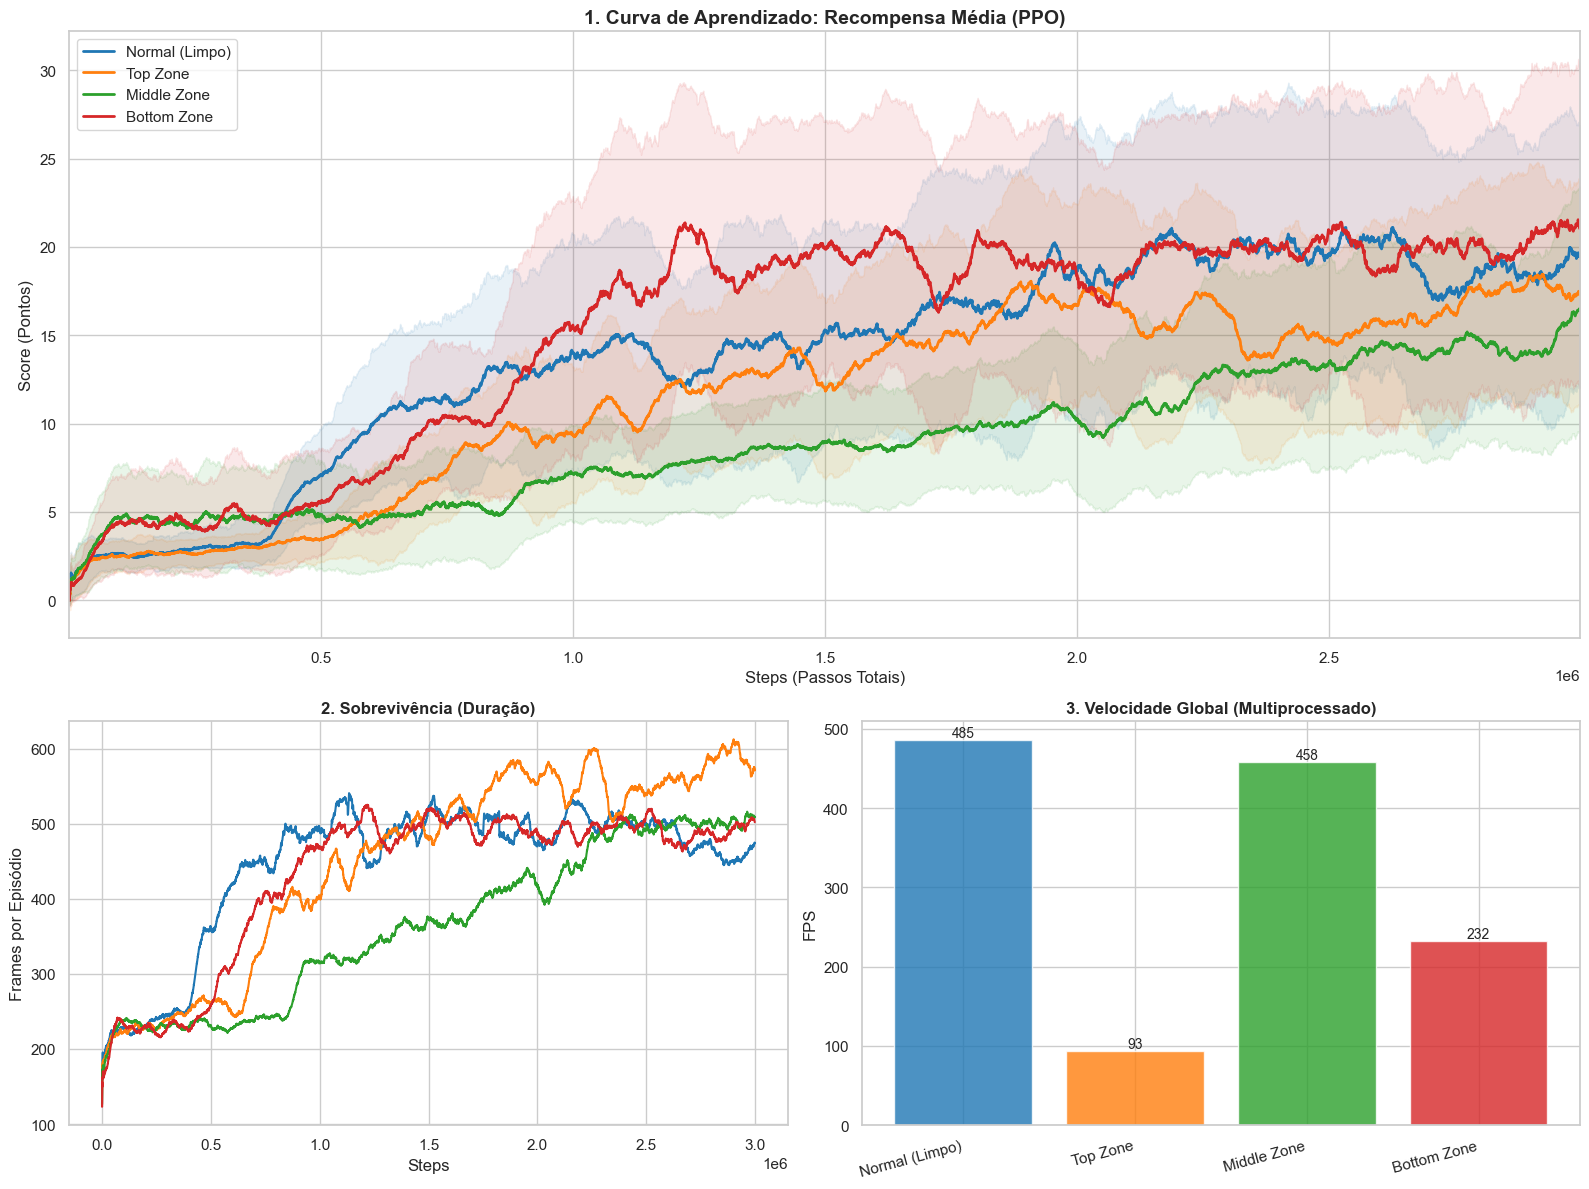

In [18]:
plot_multiline_analysis(experimentos_ppo, title_suffix="(PPO)")

In [19]:
def plot_multiline_analysis(experiments_dict, title_suffix=""):
    """
    Plota múltiplos agentes no mesmo gráfico.
    experiments_dict: Dicionário { "Nome da Legenda": "Caminho/Da/Pasta" }
    """
    
    # Configuração de Estilo
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({'font.size': 10})

    # Cores distintas para os 4 agentes (Azul, Laranja, Verde, Vermelho)
    palette = sns.color_palette("tab10", n_colors=len(experiments_dict))
    
    # Prepara os dados
    data_storage = {}
    
    for label, folder in experiments_dict.items():
        file_path = get_latest_log_file(folder)
        if file_path:
            try:
                df = pd.read_csv(file_path, skiprows=1)
                # Verifica integridade
                if {'r', 'l', 't'}.issubset(df.columns):
                    data_storage[label] = df
                else:
                    print(f"Dados corrompidos em: {label}")
            except:
                print(f"Erro ao ler: {label}")
        else:
            print(f"Log não encontrado para: {label} ({folder})")

    if not data_storage:
        print("Nenhum dado válido para plotar.")
        return

    # --- PLOTAGEM ---
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.5, 1])

    # 1. GRÁFICO DE RECOMPENSA (PRINCIPAL)
    ax1 = fig.add_subplot(gs[0, :])
    
    for i, (name, df) in enumerate(data_storage.items()):
        color = palette[i]
        x = df['l'].cumsum()
        y = df['r']
        
        # Janela de suavização dinâmica (mínimo 50, ou 1% dos dados)
        window = max(50, len(df) // 100)
        
        y_smooth = y.rolling(window=window, min_periods=1).mean()
        std_smooth = y.rolling(window=window, min_periods=1).std()
        
        ax1.plot(x, y_smooth, label=f"{name}", color=color, linewidth=2)
        # Sombra do desvio padrão (mais transparente para não poluir com 4 linhas)
        #ax1.fill_between(x, y_smooth - std_smooth, y_smooth + std_smooth, color=color, alpha=0.1)

    ax1.set_title(f"1. Learning Curve: Average Reward {title_suffix}", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Score (Points)")
    ax1.set_xlabel("Steps")
    ax1.legend(loc='upper left', fontsize=11, frameon=True)
    ax1.margins(x=0)

    # 2. GRÁFICO DE SOBREVIVÊNCIA
    ax2 = fig.add_subplot(gs[1, :])
    
    for i, (name, df) in enumerate(data_storage.items()):
        color = palette[i]
        x = df['l'].cumsum()
        window = max(50, len(df) // 100)
        y_len = df['l'].rolling(window=window, min_periods=1).mean()
        ax2.plot(x, y_len, color=color, label=name)

    ax2.set_title("2. Survival (Duration)", fontsize=12, fontweight='bold')
    ax2.set_ylabel("Frames per Episode")
    ax2.set_xlabel("Steps")
    # ax2.legend() # Opcional aqui para não poluir

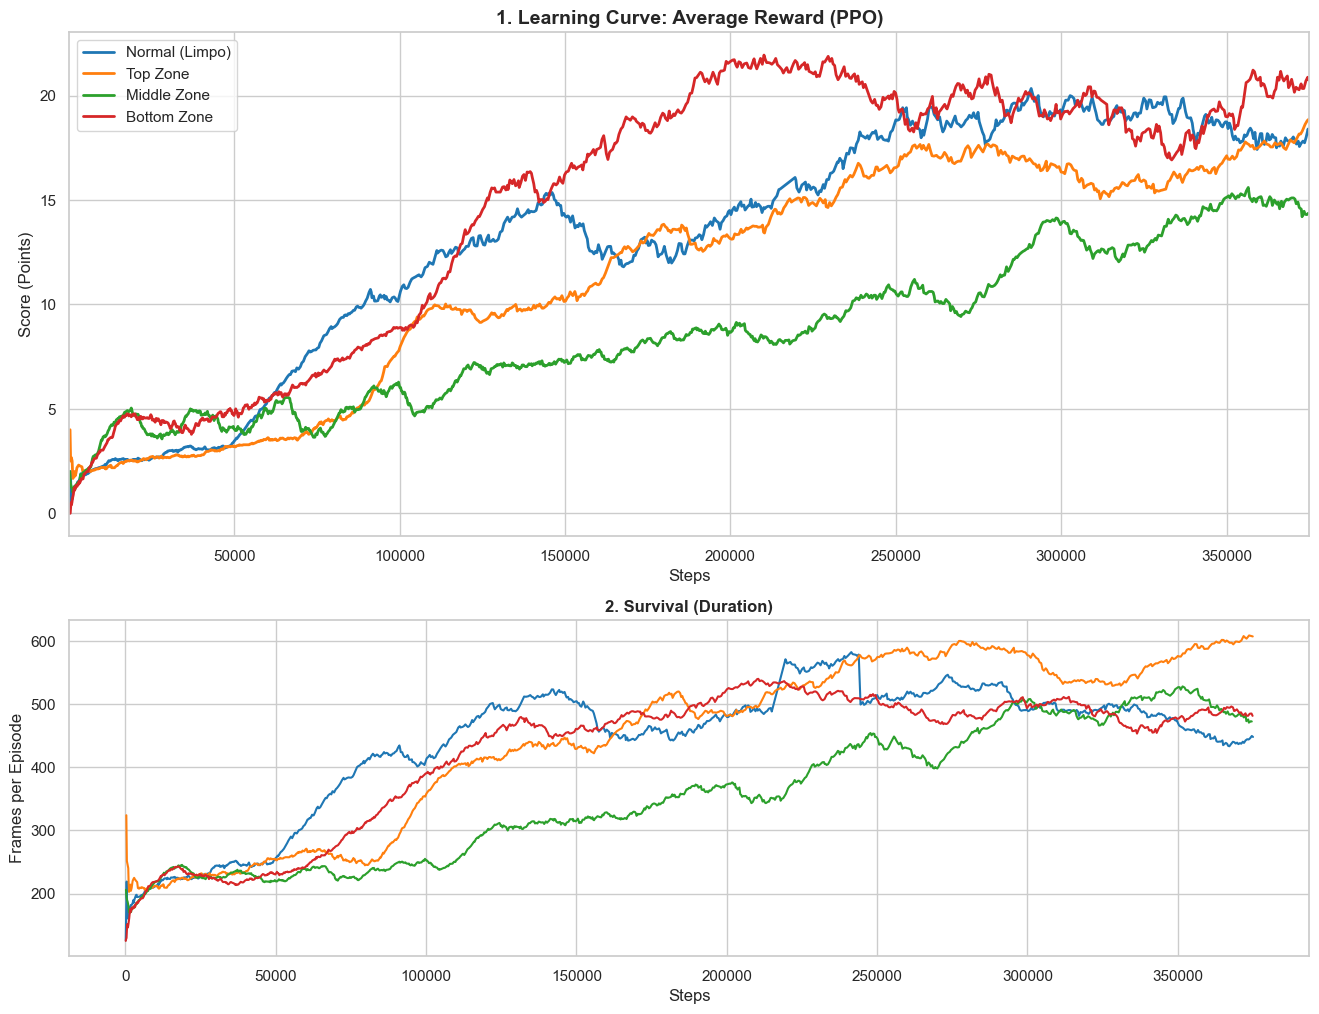

In [20]:
plot_multiline_analysis(experimentos_ppo, title_suffix="(PPO)")